In [20]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

In [178]:
data_path = 'data/TOY2/train/img'
imgs = [cv.imread(f"{data_path}/{img}") for img in os.listdir(data_path)]
sample_imgs = imgs[:8]

## Inspect images

In [177]:
def plot_samples(imgs):
    fig = plt.figure(figsize=(8., 8.))
    grid = ImageGrid(fig, 111,  # similar to subplot(111)
                    nrows_ncols=(2, 4),  # creates 2x2 grid of Axes
                    axes_pad=0.1,  # pad between Axes in inch.
                    )

    for ax, im in zip(grid, imgs):
        # Iterating over the grid returns the Axes.
        ax.imshow(im)

    plt.show()

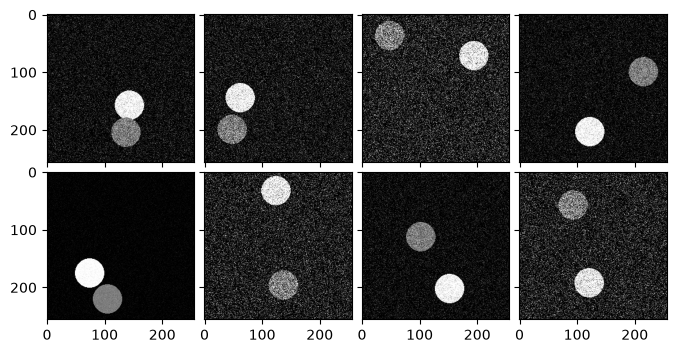

In [117]:
plot_samples(sample_imgs)

## Preprocessing 0: Clahe normalization

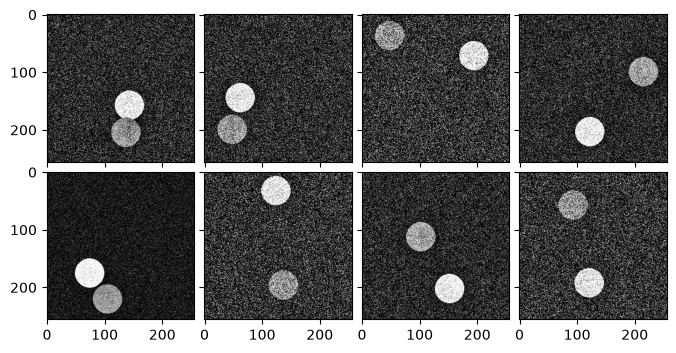

In [194]:
clahe = cv.createCLAHE(clipLimit=5, tileGridSize=(8, 8))

clahe_imgs = []
for img in sample_imgs:
    gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    clahe_img = clahe.apply(gray_img)
    clahe_img = cv.cvtColor(clahe_img, cv.COLOR_GRAY2BGR)
    #clahe_img = np.clip(clahe.apply(gray_img) + 30, 0, 255).astype(np.uint8)
    clahe_imgs.append(clahe_img)

plot_samples(clahe_imgs)

## Preprocessing 1: noise reduction

In [118]:
from scipy.ndimage import gaussian_filter
import scipy.ndimage

In [185]:
#filtered_imgs = [gaussian_filter(img, sigma=1) for img in clahe_imgs]
#plot_samples(filtered_imgs)

In [120]:
import cv2 as cv

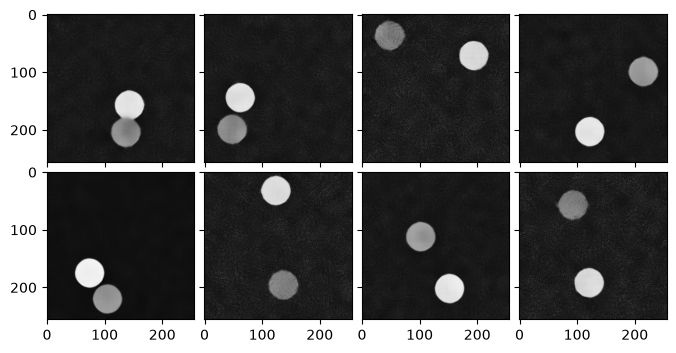

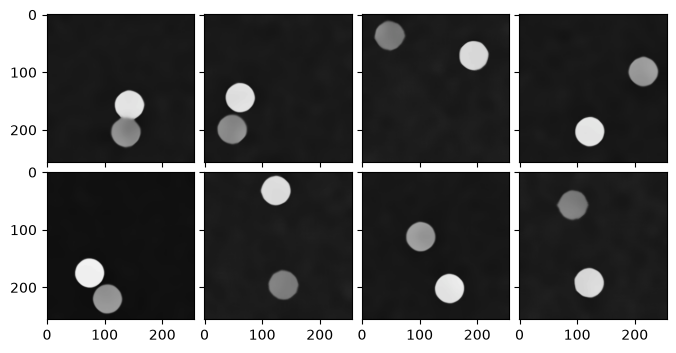

In [188]:
filtered_imgs = [cv.fastNlMeansDenoisingColored(img,None,50,50,7,21) for img in clahe_imgs]
plot_samples(filtered_imgs)
filtered_imgs = [cv.fastNlMeansDenoisingColored(img,None,20,20,7,21) for img in filtered_imgs]

plot_samples(filtered_imgs)

## Preprocessing 2: sharpen edges

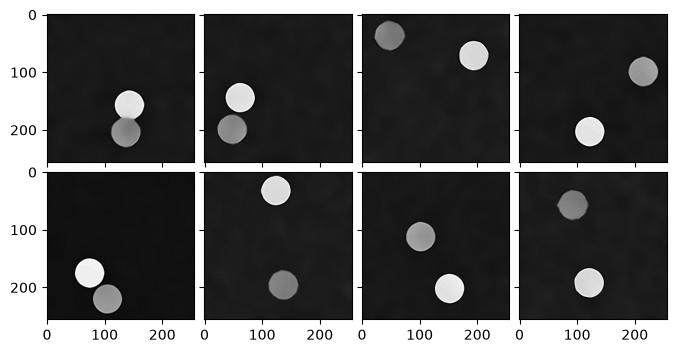

In [189]:
# Create sharpening kernel
kernel = np.array([[0, -1, 0], 
                   [-1, 5, -1],
                   [0, -1, 0]])

# Apply sharpening
sharpened_imgs = [cv.filter2D(img, -1, kernel) for img in filtered_imgs]
plot_samples(sharpened_imgs)

## Preprocessing 3: erosion

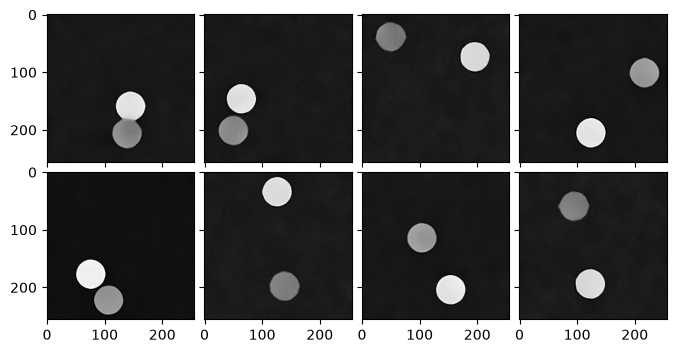

In [190]:
kernel = np.ones((2,2),np.uint8)
opened_imgs = [cv.morphologyEx(img, cv.MORPH_OPEN, kernel) for img in sharpened_imgs]
closed_imgs = [cv.morphologyEx(img, cv.MORPH_CLOSE, kernel) for img in opened_imgs]

plot_samples(closed_imgs)

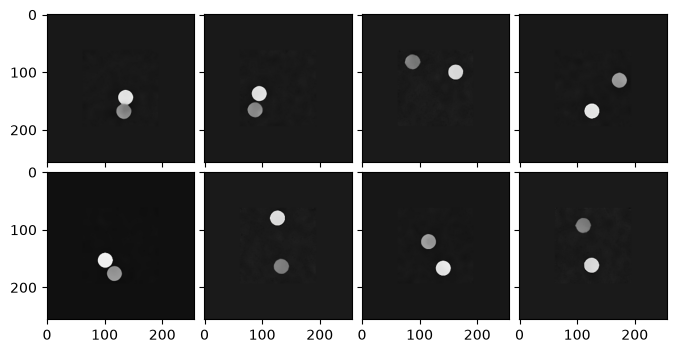

In [193]:
import nibabel as nib
from numpy.lib.stride_tricks import sliding_window_view


def median_5x5_field_value(image):
    """Return the median average value of all valid 5x5 fields."""
    if min(image.shape[:2]) < 5:
        return np.median(image, axis=(0, 1))

    fields = sliding_window_view(image, (5, 5), axis=(0, 1))
    field_averages = fields.mean(axis=(-2, -1))
    return np.median(field_averages, axis=(0, 1))


def normalize_inplane_fov(images, pixel_spacing_mm, output_shape=(256, 256), target_fov_mm=500):
    """Make image pixels represent the same physical in-plane field of view."""
    spacing_x, spacing_y = pixel_spacing_mm
    target_shape = (round(target_fov_mm / spacing_x), round(target_fov_mm / spacing_y))
    normalized = []

    for image in images:
        channels = image.shape[2:] if image.ndim > 2 else ()
        padding_value = np.asarray(median_5x5_field_value(image), dtype=image.dtype)
        canvas = np.empty((*target_shape, *channels), dtype=image.dtype)
        canvas[...] = padding_value
        source_slices = []
        target_slices = []

        for source_size, target_size in zip(image.shape[:2], target_shape):
            offset = (source_size - target_size) // 2
            source_start = max(offset, 0)
            source_stop = min(offset + target_size, source_size)
            target_start = max(-offset, 0)
            target_stop = target_start + source_stop - source_start
            source_slices.append(slice(source_start, source_stop))
            target_slices.append(slice(target_start, target_stop))

        canvas[tuple(target_slices) + (slice(None),) * len(channels)] = image[
            tuple(source_slices) + (slice(None),) * len(channels)
        ]
        normalized.append(cv.resize(canvas, output_shape[::-1], interpolation=cv.INTER_LINEAR))

    return normalized


# A CT path points to a NIfTI volume, not to spacing.pkl.
ct_path = 'data/segthor_part1/train/Patient_01/Patient_01.nii.gz'
ct_pixel_spacing_mm = nib.load(ct_path).header.get_zooms()[:2]

# sample_imgs come from TOY2 PNGs, which have no physical metadata.
# Use unit spacing for this toy visualization; use ct_pixel_spacing_mm for CT-derived slices.
pixel_normalized = normalize_inplane_fov(closed_imgs, (1.0, 1.0))
plot_samples(pixel_normalized)

In [165]:
shaped_imgs = []
for img in closed_imgs:
    img = np.dot(img[..., :3], [0.299, 0.587, 0.114])
    img = img[None, ...]
    shaped_imgs.append(img)